In [4]:
pip install matplotlib

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 5.1 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 6.0 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 7.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ölçü: 1470 sətir, 35 sütun

--- PROBLEMLƏR ---
Boş xanalar:
 Series([], dtype: int64)
Dublikatlar: 0

Silinen sətir sayı: 0
Təmiz data: 1470 sətir

Təmiz fayl saxlanıldı: clean_hr_data.xlsx


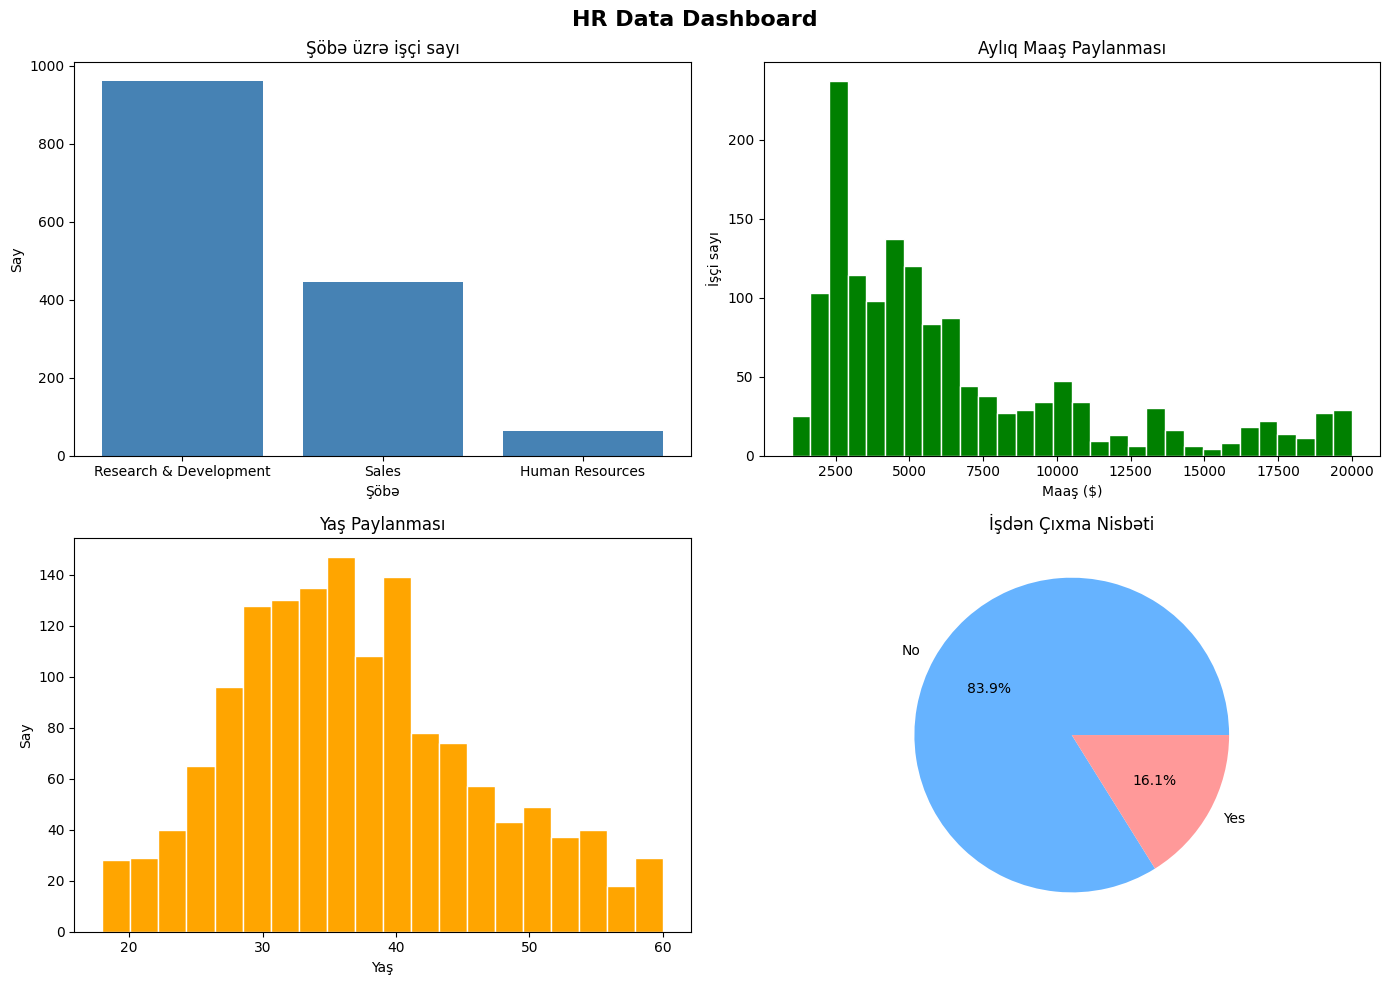

Dashboard saxlanıldı: hr_dashboard.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Ölçü: {df.shape[0]} sətir, {df.shape[1]} sütun")

print("\n--- PROBLEMLƏR ---")
print("Boş xanalar:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Dublikatlar:", df.duplicated().sum())

before_count = len(df)

df.drop_duplicates(inplace=True)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].mean())
df.drop(columns=["EmployeeCount", "Over18", "StandardHours"], inplace=True)
df["Department"] = df["Department"].str.strip().str.title()
df["Gender"] = df["Gender"].str.strip().str.title()

after_count = len(df)
print(f"\nSilinen sətir sayı: {before_count - after_count}")
print(f"Təmiz data: {after_count} sətir")

df.to_excel("clean_hr_data.xlsx", index=False)
print("\nTəmiz fayl saxlanıldı: clean_hr_data.xlsx")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("HR Data Dashboard", fontsize=16, fontweight="bold")

dept_counts = df["Department"].value_counts()
axes[0, 0].bar(dept_counts.index, dept_counts.values, color="steelblue")
axes[0, 0].set_title("Şöbə üzrə işçi sayı")
axes[0, 0].set_xlabel("Şöbə")
axes[0, 0].set_ylabel("Say")

axes[0, 1].hist(df["MonthlyIncome"], bins=30, color="green", edgecolor="white")
axes[0, 1].set_title("Aylıq Maaş Paylanması")
axes[0, 1].set_xlabel("Maaş ($)")
axes[0, 1].set_ylabel("İşçi sayı")

axes[1, 0].hist(df["Age"], bins=20, color="orange", edgecolor="white")
axes[1, 0].set_title("Yaş Paylanması")
axes[1, 0].set_xlabel("Yaş")
axes[1, 0].set_ylabel("Say")

attrition = df["Attrition"].value_counts()
axes[1, 1].pie(attrition.values, labels=attrition.index,
               autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
axes[1, 1].set_title("İşdən Çıxma Nisbəti")

plt.tight_layout()
plt.savefig("hr_dashboard.png", dpi=150)
plt.show()
print("Dashboard saxlanıldı: hr_dashboard.png")

In [9]:
!git init
!git add .
!git commit -m "HR data cleaning and dashboard project"
!git branch -M main
!git remote add origin https://github.com/Dicapso/hr-data-cleaning.git
!git push -u origin main

'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
